# Probe Analysis

Train logistic-regression probes on JudgementLM attention activations and
evaluate at predicting valid/invalid labels.

**Labels** are the union of:
- `judgement_combined` — majority-vote LLM judge output
- `matching_status`    — whether the extraction matches a ground-truth row

**Analyses**
1. Baseline: raw judge model accuracy
2. Single-head selection: score every (layer, head) pair; visualise heatmap,
   PCA, calibration, probability distribution
3. Iterative greedy selection: sequentially add the head with the highest
   marginal contribution; same visualisations per iteration

In [1]:
import sys
from pathlib import Path
%load_ext autoreload
%autoreload 2

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))
sys.path.insert(0, str(REPO_ROOT / 'experiments'))
sys.path.insert(0, str(REPO_ROOT))

In [38]:
DATASET          = 'pond_ten'
EXTRACTION_MODEL = 'gemma-3-27b'
EXTRACTION_DATE  = '2026_04_14'
JUDGE_MODEL      = 'llama-3.1-8b'
TOP_K            = 5   # number of greedy iterations
N_FOLDS          = 5

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from analysis.loaders import (
    load_activations, load_combined_judgements,
    load_extraction, load_ground_truth, cached_match,
)
from analysis.plots import calibration_curve, probability_distribution
from scholarlm.utils.probe import (
    get_head_features, grouped_kfold_split, grouped_holdout_split,
    train_probe, eval_probe, eval_probe_detailed,
)
from scholarlm.utils.calibration import reliability_diagram_data
from scholarlm.utils.unit_conversion import apply_unit_conversion
from experiments.run_extraction import load_dataset_config
import paths

# Ensure figures directory exists
FIGURES_DIR = paths.figures_dir(DATASET)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [40]:
activations = load_activations(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE, JUDGE_MODEL)
judgements  = load_combined_judgements(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE)
judged_df   = pd.DataFrame(judgements)

config          = load_dataset_config(DATASET)
records         = load_extraction(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE)
extraction_df   = pd.DataFrame(records)
extraction_df   = apply_unit_conversion(extraction_df, config.unit_conversion_table)
ground_truth_df = load_ground_truth(config)

print(f'Activations:  {len(activations.files)} entries')
print(f'Judgements:   {len(judged_df)} records')
print(f'Extraction:   {len(extraction_df)} records')
print(f'Ground truth: {len(ground_truth_df)} records')

Activations:  4519 entries
Judgements:   4519 records
Extraction:   4519 records
Ground truth: 1301 records


In [135]:
print(judged_df.groupby('title')['judgement_combined'].agg(['mean', 'count']).sort_values('mean'))

                                                        mean  count
title                                                              
physical-chemical influences on vernal zooplank...  0.194647    822
physical and chemical limnological characterist...  0.237931    580
relationships between fish feeding guild and tr...  0.266667    240
net heterotrophy in small danish lakes: a wides...  0.305085    118
impact of macrophytes on phytoplankton in eutro...  0.404624    173
habitat characteristics and odonate diversity i...  0.537879    132
environmental conditions and macrophytes of kar...  0.568199   1327
prairie wetland communities recover at differen...  0.627957    465
classification trees as a tool for predicting c...  0.776650    197
macroinvertebrate size spectra of mediterranean...  0.967742    465


In [136]:
# Load ground-truth matching from cache (produced by extraction_analysis.ipynb)
if 'pond' in DATASET:
    STRICT_MATCHING = {'title': 'title', 'attribute': 'attribute', 'converted_value': 'value'}
    FUZZY_MATCHING  = {'name': 'name', 'location': 'location', 'ecosystem': 'ecosystem'}
elif 'nfix' in DATASET:
    extraction_df['attribute'] = extraction_df['attribute'].map({'nfix_rate_areal': 'nfix_rate', 'nfix_rate_volumetric': 'nfix_rate', 'nfix_rate_mass': 'nfix_rate'})
    STRICT_MATCHING = {'paper_code': 'reference_id', 'attribute': 'attribute', 'converted_value': 'value'}
    FUZZY_MATCHING  = {"name": "site_name", "site_type": "habitat"}
else:
    raise ValueError("Dataset not recognized.")


cache_path = paths.extraction(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE) / 'match_cache.pkl'
#cache_path = None

matching, _edges, _weights = cached_match(
    extraction_df, ground_truth_df,
    strict_matching=STRICT_MATCHING,
    fuzzy_matching=FUZZY_MATCHING,
    fuzzy_threshold=0.0,
    cache_path=cache_path,
)

# Index matching status by measurement_id string
matching_by_id = {}
for _gt_idx, ex_idx in matching:
    mid = str(extraction_df.iloc[ex_idx]['measurement_id'])
    matching_by_id[mid] = True

# Restrict to records that have activation entries
act_keys = set(activations.files)
records_with_act = (
    judged_df[judged_df['measurement_id'].astype(str).isin(act_keys)]
    .reset_index(drop=True)
)
measurement_ids = list(records_with_act['measurement_id'])
titles = records_with_act['title'].values
# Build page-level group key: (title, first_page)
# page_number is stored as a list, e.g. [1]; use first element as the page id
_page_nums = records_with_act['page_number'].apply(
    lambda v: v[0] if isinstance(v, list) and v else 0
).values
page_groups = np.array([f'{t}__p{p}' for t, p in zip(titles, _page_nums)])
page_groups = np.array([p + '_' + str(i) for i,p in enumerate(page_groups)])

page_groups = np.array(titles)

# Labels = judgement_combined OR matching_status (union)
jlabels = records_with_act['judgement_combined'].values.astype(bool)
mlabels = np.array([matching_by_id.get(str(m), False) for m in measurement_ids])
labels  = jlabels | mlabels
labels = mlabels

print(f'n={len(labels)}  positive rate={labels.mean():.2%}')
print(f'  Judgement only: {(jlabels & ~mlabels).sum()}')
print(f'  Matching only:  {(~jlabels & mlabels).sum()}')
print(f'  Both:           {(jlabels & mlabels).sum()}')

n=4519  positive rate=20.76%
  Judgement only: 1786
  Matching only:  536
  Both:           402


In [138]:
# ── Global train / calibration / test split ──────────────────────────────────
# These three pools are entirely separate from one another.
# cv_idx   → head selection (5-fold CV) + final probe training
# cal_idx  → Platt scaling of the trained probe
# test_idx → strictly held-out final evaluation

cv_idx, cal_idx, test_idx = grouped_holdout_split(
    page_groups, train_frac=0.60, cal_frac=0.15, random_state=42
)
labels_cv      = labels[cv_idx]
page_groups_cv = page_groups[cv_idx]

print(f'Global split (total n={len(labels)}):')
print(f'  CV pool : {len(cv_idx):4d} ({len(cv_idx)/len(labels):.1%})  pos={labels_cv.mean():.2%}')
print(f'  Cal set : {len(cal_idx):4d} ({len(cal_idx)/len(labels):.1%})  pos={labels[cal_idx].mean():.2%}')
print(f'  Test set: {len(test_idx):4d} ({len(test_idx)/len(labels):.1%})  pos={labels[test_idx].mean():.2%}')

Global split (total n=4519):
  CV pool : 2929 (64.8%)  pos=24.21%
  Cal set :  837 (18.5%)  pos=11.35%
  Test set:  753 (16.7%)  pos=17.80%


## Baseline: Raw Judge Performance

In [139]:
judge_preds = records_with_act[f'judgement_{JUDGE_MODEL}'].astype(bool).values

tp = int(( judge_preds[test_idx] &  labels[test_idx]).sum())
tn = int((~judge_preds[test_idx] & ~labels[test_idx]).sum())
fp = int(( judge_preds[test_idx] & ~labels[test_idx]).sum())
fn = int((~judge_preds[test_idx] &  labels[test_idx]).sum())
n  = len(labels[test_idx])

acc  = (tp + tn) / n
prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
rec  = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else float('nan')

print('Raw judge model performance (against union labels):')
print(f'  Accuracy:  {acc:.4f}')
print(f'  Precision: {prec:.4f}')
print(f'  Recall:    {rec:.4f}')
print(f'  F1:        {f1:.4f}')
print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}')

Raw judge model performance (against union labels):
  Accuracy:  0.8167
  Precision: 0.4714
  Recall:    0.2463
  F1:        0.3235
  TP=33  TN=582  FP=37  FN=101


In [105]:
# Infer shape from first entry
_arr0 = np.array(activations[str(measurement_ids[0])], dtype=np.float32)
n_layers, n_heads, head_dim = _arr0.shape
print(f'Activation shape: n_layers={n_layers}, n_heads={n_heads}, head_dim={head_dim}')
print(f'Total heads: {n_layers * n_heads}')

# Load all activations into memory (one pass) then build per-head matrices
print('Loading activations into memory...')
_all_act = {
    str(mid): np.array(activations[str(mid)], dtype=np.float32)
    for mid in measurement_ids
}

print('Building per-head feature matrices...')
head_datasets: dict[tuple[int, int], np.ndarray] = {}
for l in range(n_layers):
    for h in range(n_heads):
        head_datasets[(l, h)] = np.stack(
            [_all_act[str(mid)][l, h, :] for mid in measurement_ids], axis=0
        )
del _all_act  # free memory
print(f'Done. Each head dataset shape: {head_datasets[(0, 0)].shape}')

Activation shape: n_layers=32, n_heads=32, head_dim=128
Total heads: 1024
Loading activations into memory...
Building per-head feature matrices...
Done. Each head dataset shape: (4519, 128)


## 1. Single-Head Selection

Score every (layer, head) pair with group-based 5-fold cross-validation,
then visualise the accuracy heatmap, PCA, calibration, and probability
distributions for the top head.

In [140]:
def cv_score(X, y, groups, n_folds=N_FOLDS):
    """Group k-fold CV.  All inputs must already be indexed to the CV pool.

    Returns (mean_acc, fold_accs, mean_auroc, fold_aurocs, mean_f1, fold_f1s, oof_probs).
    oof_probs is aligned to the input array (length == len(y)).
    """
    probe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=10,
            class_weight=None,
            solver='lbfgs',
            max_iter=1000,
            random_state=42,
        ))
    ])

    fold_accs, fold_aurocs, fold_f1s = [], [], []
    fold_test_idx, fold_probs_list = [], []

    for train_idx, test_idx in grouped_kfold_split(groups, n_splits=n_folds):
        probe.fit(X[train_idx], y[train_idx])
        y_pred = probe.predict(X[test_idx])
        y_true = y[test_idx]
        probs  = probe.predict_proba(X[test_idx])[:, 1]

        fold_accs.append(float((y_pred == y_true).mean()))

        auroc = (roc_auc_score(y_true, probs)
                 if y_true.sum() > 0 and (~y_true).sum() > 0
                 else float('nan'))
        fold_aurocs.append(auroc)

        tp   = int(( y_pred &  y_true).sum())
        fp   = int(( y_pred & ~y_true).sum())
        fn   = int((~y_pred &  y_true).sum())
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        fold_f1s.append(f1)

        fold_test_idx.extend(test_idx)
        fold_probs_list.append(probs)

    oof_probs  = np.empty(len(y))
    sort_order = np.argsort(fold_test_idx)
    oof_probs[np.array(fold_test_idx)[sort_order]] = np.concatenate(fold_probs_list)[sort_order]

    return (
        float(np.mean(fold_accs)),          list(fold_accs),
        float(np.nanmean(fold_aurocs)),      list(fold_aurocs),
        float(np.mean(fold_f1s)),            list(fold_f1s),
        oof_probs,
    )

In [141]:
print(f'Scoring {n_layers * n_heads} heads on CV pool (n={len(cv_idx)})...')
head_scores_acc   = np.zeros((n_layers, n_heads))
head_scores_auroc = np.zeros((n_layers, n_heads))
head_scores_f1    = np.zeros((n_layers, n_heads))
head_fold_accs    = {}
head_fold_aurocs  = {}
head_fold_f1s     = {}
head_oof_probs    = {}  # OOF probs aligned to cv_idx (length = len(cv_idx))

for l in range(n_layers):
    for h in range(n_heads):
        X_cv = head_datasets[(l, h)][cv_idx]
        (mean_acc,   fold_accs,
         mean_auroc, fold_aurocs,
         mean_f1,    fold_f1s,
         oof_probs) = cv_score(X_cv, labels_cv, page_groups_cv)

        head_scores_acc[l, h]    = mean_acc
        head_scores_auroc[l, h]  = mean_auroc
        head_scores_f1[l, h]     = mean_f1
        head_fold_accs[(l, h)]   = fold_accs
        head_fold_aurocs[(l, h)] = fold_aurocs
        head_fold_f1s[(l, h)]    = fold_f1s
        head_oof_probs[(l, h)]   = oof_probs
    if (l + 1) % 8 == 0:
        print(f'  Layer {l + 1}/{n_layers} done')

Scoring 1024 heads on CV pool (n=2929)...
  Layer 8/32 done
  Layer 16/32 done
  Layer 24/32 done
  Layer 32/32 done


In [144]:
# Select best head
head_scores = head_scores_f1
best_l, best_h = np.unravel_index(head_scores.argmax(), head_scores.shape)
print(f'Best head: layer={best_l}, head={best_h}')
print(f'  AUROC={head_scores_auroc[best_l, best_h]:.4f}  '
      f'F1={head_scores_f1[best_l, best_h]:.4f}  '
      f'Acc={head_scores_acc[best_l, best_h]:.4f}')

Best head: layer=3, head=1
  AUROC=0.7158  F1=0.5106  Acc=0.8049


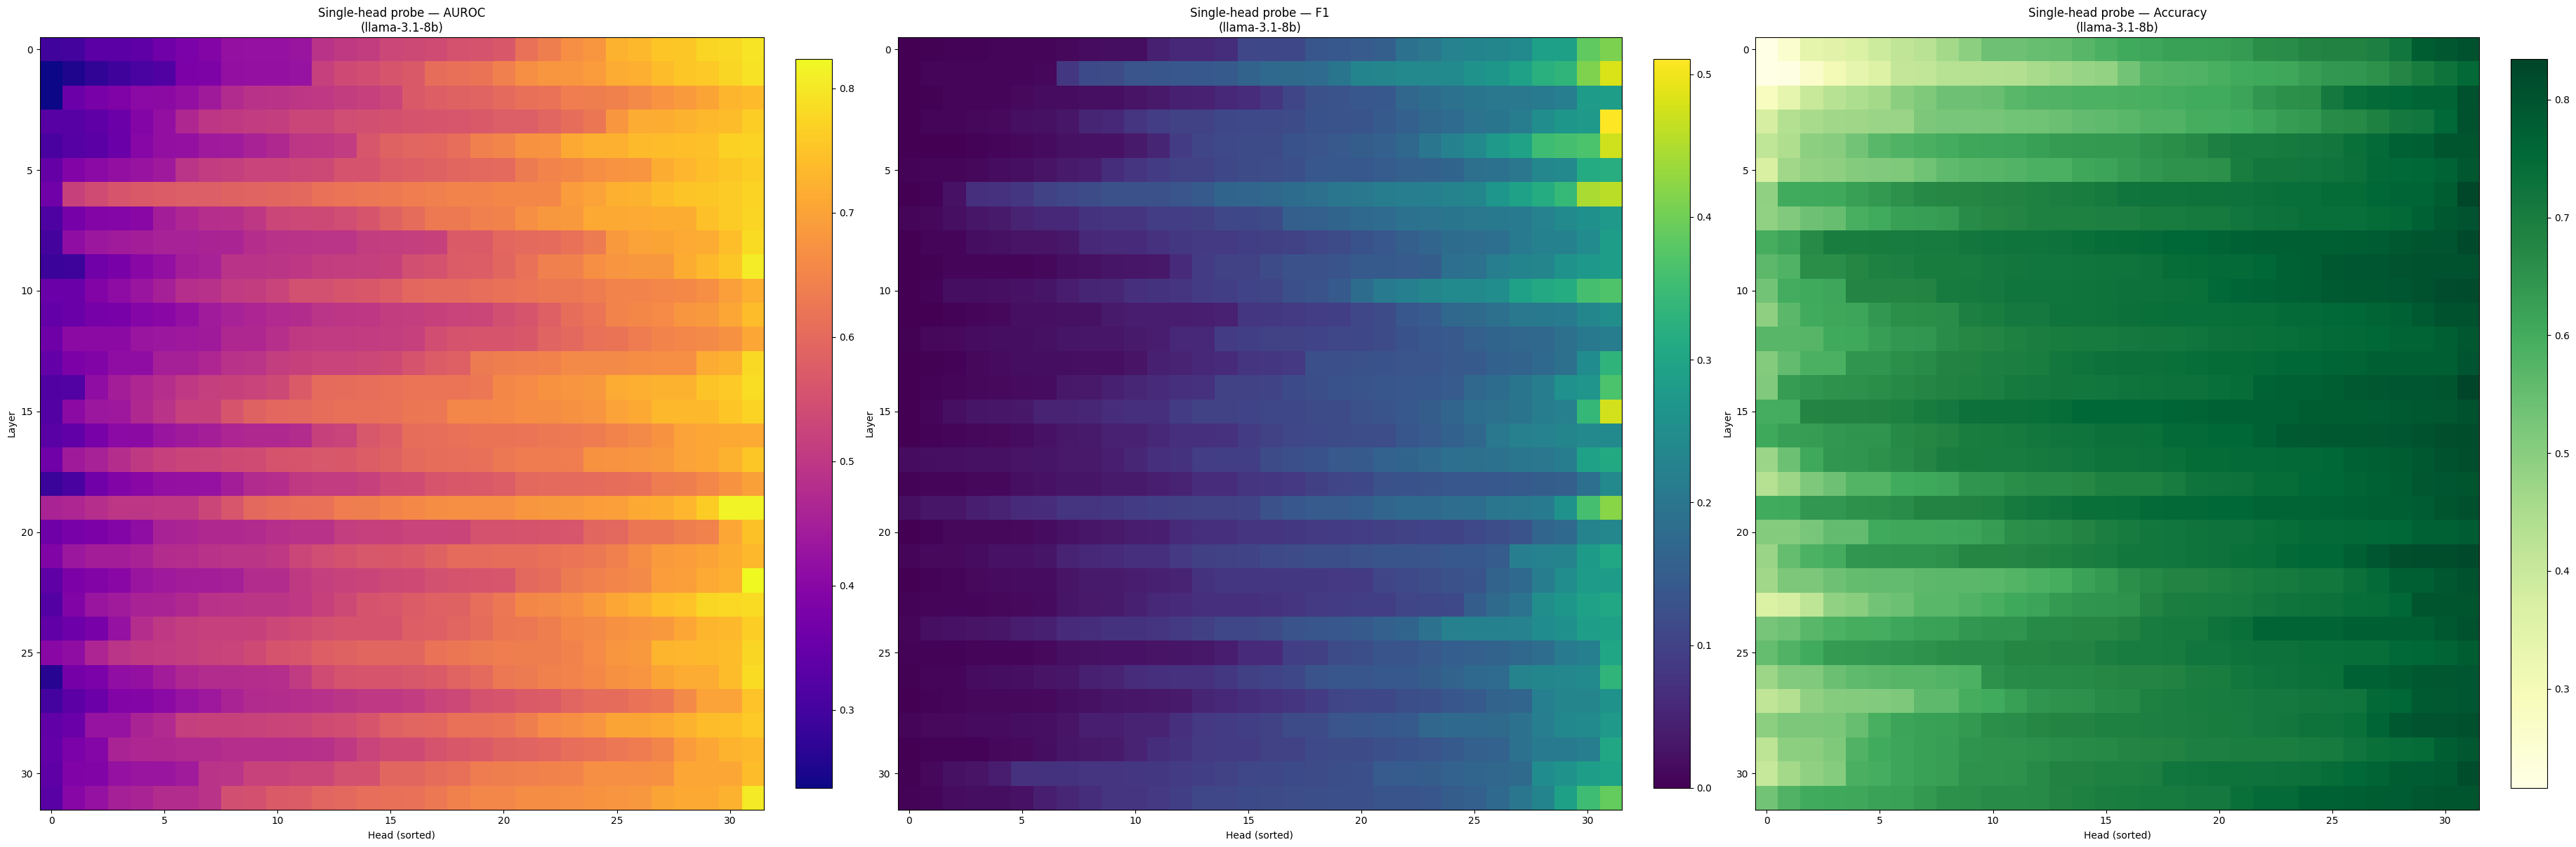

In [145]:
fig, axes = plt.subplots(1, 3, figsize=(max(18, n_heads * 1.15), max(4, n_layers * 0.38)))

for ax, score_mat, title, cmap in [
    (axes[0], head_scores_auroc, 'AUROC',    'plasma'),
    (axes[1], head_scores_f1,    'F1',       'viridis'),
    (axes[2], head_scores_acc,   'Accuracy', 'YlGn'),
]:
    im = ax.imshow(np.sort(score_mat, axis=1), cmap=cmap, aspect='auto')
    ax.set_xlabel('Head (sorted)')
    ax.set_ylabel('Layer')
    ax.set_title(f'Single-head probe — {title}\n({JUDGE_MODEL})')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
#fig.savefig(FIGURES_DIR / 'probe_single_head_heatmaps.pdf', bbox_inches='tight')

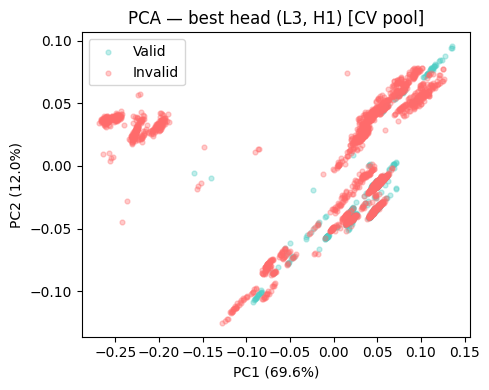

In [146]:
X_best = head_datasets[(best_l, best_h)][cv_idx]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_best)

fig, ax = plt.subplots(figsize=(5, 4))
for val, label_str, color in [(True, 'Valid', '#4ECDC4'), (False, 'Invalid', '#FF6B6B')]:
    mask = labels_cv == val
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, alpha=0.35, s=12, label=label_str)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'PCA — best head (L{best_l}, H{best_h}) [CV pool]')
ax.legend()
fig.tight_layout()
#fig.savefig(FIGURES_DIR / 'probe_single_head_pca.pdf', bbox_inches='tight')

Single best head CV-OOF ECE = 0.1428


Text(0.5, 1.0, 'Calibration (CV OOF) — best head (L31, H5)')

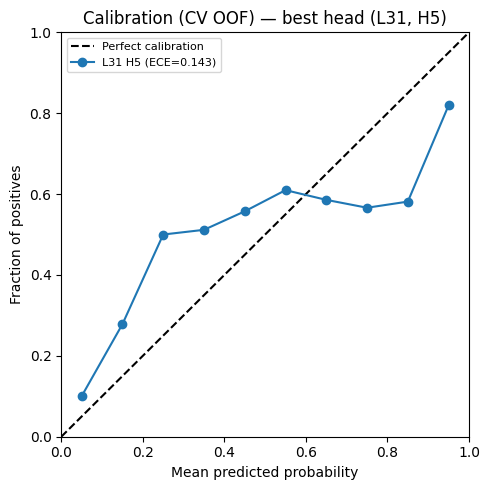

In [128]:
oof_probs_single = head_oof_probs[(best_l, best_h)]
diag_single = reliability_diagram_data(oof_probs_single, labels_cv)
print(f'Single best head CV-OOF ECE = {diag_single["ece"]:.4f}')

fig = calibration_curve(diag_single, judge_labels=[f'L{best_l} H{best_h}'])
fig.axes[0].set_title(f'Calibration (CV OOF) — best head (L{best_l}, H{best_h})')
#fig.savefig(FIGURES_DIR / 'probe_single_head_calibration.pdf', bbox_inches='tight')

Text(0.5, 1.0, 'Prob distribution (CV OOF) — best head (L31, H5)')

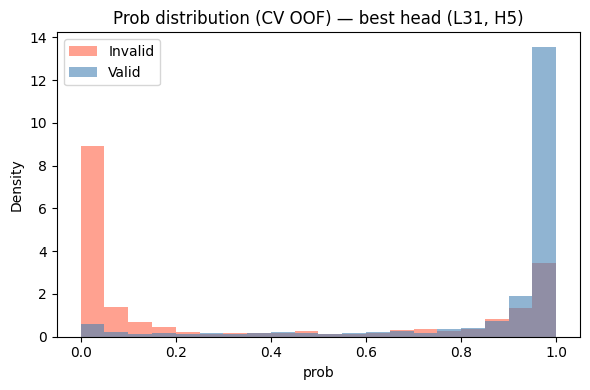

In [129]:
_df_single = pd.DataFrame({'prob': oof_probs_single, 'label': labels_cv})
fig = probability_distribution(_df_single, prob_col='prob', label_col='label')
fig.axes[0].set_title(f'Prob distribution (CV OOF) — best head (L{best_l}, H{best_h})')
#fig.savefig(FIGURES_DIR / 'probe_single_head_prob_dist.pdf', bbox_inches='tight')

In [68]:
oof_preds_single = oof_probs_single > 0.5
tp_ = int(( oof_preds_single &  labels_cv).sum())
tn_ = int((~oof_preds_single & ~labels_cv).sum())
fp_ = int(( oof_preds_single & ~labels_cv).sum())
fn_ = int((~oof_preds_single &  labels_cv).sum())
n_  = len(labels_cv)
acc_   = (tp_ + tn_) / n_
prec_  = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else float('nan')
rec_   = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else float('nan')
f1_    = 2 * prec_ * rec_ / (prec_ + rec_) if (prec_ + rec_) > 0 else float('nan')
auroc_ = roc_auc_score(labels_cv, oof_probs_single)

print(f'=== Single-head probe CV OOF summary (layer={best_l}, head={best_h}) ===')
print(f'  Accuracy:  {acc_:.4f}')
print(f'  Precision: {prec_:.4f}')
print(f'  Recall:    {rec_:.4f}')
print(f'  F1:        {f1_:.4f}')
print(f'  AUROC:     {auroc_:.4f}')
print(f'  TP={tp_}  TN={tn_}  FP={fp_}  FN={fn_}  n={n_}')

=== Single-head probe CV OOF summary (layer=18, head=14) ===
  Accuracy:  0.7055
  Precision: 0.7637
  Recall:    0.7852
  F1:        0.7743
  AUROC:     0.6814
  TP=1532  TN=607  FP=474  FN=419  n=3032


In [69]:
print(f'=== Single-head probe CV summary (layer={best_l}, head={best_h}) ===')
print(f'  5-fold CV AUROC: {head_scores_auroc[best_l, best_h]:.4f} '
      f'+/- {np.std(head_fold_aurocs[(best_l, best_h)]):.4f}')
print(f'  5-fold CV F1:    {head_scores_f1[best_l, best_h]:.4f} '
      f'+/- {np.std(head_fold_f1s[(best_l, best_h)]):.4f}')
print(f'  5-fold CV Acc:   {head_scores_acc[best_l, best_h]:.4f} '
      f'+/- {np.std(head_fold_accs[(best_l, best_h)]):.4f}')

=== Single-head probe CV summary (layer=18, head=14) ===
  5-fold CV AUROC: 0.6919 +/- 0.0881
  5-fold CV F1:    0.7168 +/- 0.0980
  5-fold CV Acc:   0.6687 +/- 0.1035


## Final Single-Head Probe

Train on the full CV pool, re-calibrate with Platt scaling on the calibration set, evaluate on the held-out test set.

In [147]:
def _probe_metrics(probs, y_true, label):
    """Print and return evaluation metrics for a set of probabilities."""
    preds = probs > 0.5
    tp  = int(( preds &  y_true).sum())
    tn  = int((~preds & ~y_true).sum())
    fp  = int(( preds & ~y_true).sum())
    fn  = int((~preds &  y_true).sum())
    n   = len(y_true)
    acc  = (tp + tn) / n
    prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    rec  = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else float('nan')
    auroc = (roc_auc_score(y_true, probs)
             if y_true.sum() > 0 and (~y_true).sum() > 0 else float('nan'))
    ece  = reliability_diagram_data(probs, y_true)['ece']
    print(f'{label}:')
    print(f'  Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
    print(f'  AUROC={auroc:.4f}  ECE={ece:.4f}')
    print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}  n={n}')
    return probs

=== Final single-head probe (L3, H1) — test set ===

Uncalibrated:
  Accuracy=0.9296  Precision=0.9175  Recall=0.6642  F1=0.7706
  AUROC=0.9278  ECE=0.0625
  TP=89  TN=611  FP=8  FN=45  n=753

Platt-calibrated:
  Accuracy=0.9283  Precision=0.9167  Recall=0.6567  F1=0.7652
  AUROC=0.9278  ECE=0.0803
  TP=88  TN=611  FP=8  FN=46  n=753


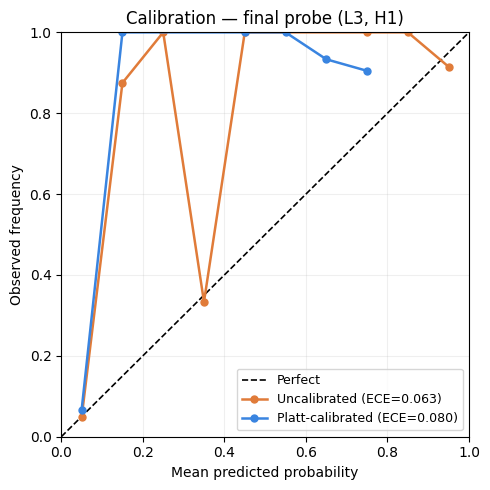

In [148]:
# ── Final Single-Head Probe: Training + Platt Scaling + Test Evaluation ───────

X_cv_s   = head_datasets[(best_l, best_h)][cv_idx]
X_cal_s  = head_datasets[(best_l, best_h)][cal_idx]
X_test_s = head_datasets[(best_l, best_h)][test_idx]
y_cv_s, y_cal_s, y_test_s = labels[cv_idx], labels[cal_idx], labels[test_idx]

# Train final probe on the CV pool
final_probe_single = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0, class_weight='balanced', solver='lbfgs',
        max_iter=1000, random_state=42,
    ))
]).fit(X_cv_s, y_cv_s)

# Platt scaling: 1-D logistic regression on calibration-set probabilities
raw_cal_s = final_probe_single.predict_proba(X_cal_s)[:, 1].reshape(-1, 1)
platt_single = LogisticRegression(C=1e6, solver='lbfgs', max_iter=1000).fit(raw_cal_s, y_cal_s)

# Test-set probabilities
raw_test_s = final_probe_single.predict_proba(X_test_s)[:, 1]
cal_test_s = platt_single.predict_proba(raw_test_s.reshape(-1, 1))[:, 1]

print(f'=== Final single-head probe (L{best_l}, H{best_h}) — test set ===\n')
_probe_metrics(raw_test_s, y_test_s, 'Uncalibrated')
print()
_probe_metrics(cal_test_s, y_test_s, 'Platt-calibrated')

# Calibration curves
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect')
for probs, label, color in [
    (raw_test_s, 'Uncalibrated',     '#e07b39'),
    (cal_test_s, 'Platt-calibrated', '#3984e0'),
]:
    d = reliability_diagram_data(probs, y_test_s)
    valid = ~np.isnan(d['bin_accuracy'])
    ax.plot(d['bin_centers'][valid], d['bin_accuracy'][valid], 'o-',
            color=color, lw=1.8, ms=5, label=f"{label} (ECE={d['ece']:.3f})")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed frequency')
ax.set_title(f'Calibration — final probe (L{best_l}, H{best_h})')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
fig.tight_layout()
#fig.savefig(FIGURES_DIR / 'probe_final_single_calibration.pdf', bbox_inches='tight')

In [150]:
1.95 / 4500 * 1000

0.4333333333333333

## 2. Iterative Greedy Head Selection

Sequentially add the attention head that maximally improves probe accuracy.
Iteration 1 reuses the single-head CV scores computed above.
Subsequent iterations evaluate each remaining head concatenated to the
current selected feature set.

In [ ]:
iteration_history = []
selected_heads    = []
combined_X_cv     = None   # growing feature matrix restricted to the CV pool
remaining         = [(l, h) for l in range(n_layers) for h in range(n_heads)]

print(f'GREEDY FORWARD HEAD SELECTION  k={TOP_K}\n' + '=' * 60)

for iteration in range(TOP_K):
    print(f'\n--- Iteration {iteration + 1} ---')

    auroc_matrix  = np.full((n_layers, n_heads), np.nan)
    f1_matrix     = np.full((n_layers, n_heads), np.nan)
    fold_per_head = {}
    oof_per_head  = {}

    for (l, h) in remaining:
        X_head_cv = head_datasets[(l, h)][cv_idx]
        X_cand    = X_head_cv if combined_X_cv is None \
                    else np.concatenate([combined_X_cv, X_head_cv], axis=1)

        if iteration == 0:
            mean_auroc  = head_scores_auroc[l, h]
            fold_aurocs = head_fold_aurocs[(l, h)]
            mean_f1     = head_scores_f1[l, h]
            fold_f1s    = head_fold_f1s[(l, h)]
            oof_probs   = head_oof_probs[(l, h)]
        else:
            (_, _,
             mean_auroc, fold_aurocs,
             mean_f1,    fold_f1s,
             oof_probs) = cv_score(X_cand, labels_cv, page_groups_cv)

        auroc_matrix[l, h]    = mean_auroc
        f1_matrix[l, h]       = mean_f1
        fold_per_head[(l, h)] = {'auroc': fold_aurocs, 'f1': fold_f1s}
        oof_per_head[(l, h)]  = oof_probs

    # Select by AUROC
    valid_heads = [(l, h) for (l, h) in remaining if not np.isnan(auroc_matrix[l, h])]
    best_lh     = max(valid_heads, key=lambda k: auroc_matrix[k])
    bl, bh      = best_lh
    best_auroc  = float(auroc_matrix[bl, bh])
    best_f1     = float(f1_matrix[bl, bh])
    print(f'  Selected: layer={bl:2d}, head={bh:2d}  AUROC={best_auroc:.4f}  F1={best_f1:.4f}')

    # Mask previously selected heads for visualisation
    vis_auroc = auroc_matrix.copy()
    vis_f1    = f1_matrix.copy()
    for sl, sh in selected_heads:
        vis_auroc[sl, sh] = np.nan
        vis_f1[sl, sh]    = np.nan

    # Update state
    X_best_head_cv = head_datasets[best_lh][cv_idx]
    combined_X_cv  = (X_best_head_cv.copy() if combined_X_cv is None
                      else np.concatenate([combined_X_cv, X_best_head_cv], axis=1))
    remaining.remove(best_lh)
    selected_heads.append(best_lh)

    iteration_history.append({
        'iteration':         iteration + 1,
        'selected_layer':    bl,
        'selected_head':     bh,
        'marginal_auroc':    best_auroc,
        'marginal_f1':       best_f1,
        'fold_aurocs':       fold_per_head[best_lh]['auroc'],
        'fold_f1s':          fold_per_head[best_lh]['f1'],
        'head_auroc_matrix': vis_auroc,
        'head_f1_matrix':    vis_f1,
        'combined_features': combined_X_cv.copy(),
        'oof_probs':         oof_per_head[best_lh],
        'oof_labels':        labels_cv.copy(),
    })

print('\nDone.')

### Visualisation 1 — Head Accuracy Heatmaps per Iteration

In [ ]:
fig, axes = plt.subplots(2, TOP_K, figsize=(TOP_K * 4.2, 7.5))
if TOP_K == 1:
    axes = axes.reshape(2, 1)

for i, data in enumerate(iteration_history):
    for row, (mat_key, metric_label, cmap) in enumerate([
        ('head_auroc_matrix', 'AUROC', 'plasma'),
        ('head_f1_matrix',    'F1',    'viridis'),
    ]):
        ax  = axes[row, i]
        mat = data[mat_key].copy()

        if i > 0:
            prev_val = iteration_history[i - 1][f'marginal_{metric_label.lower()}']
            mat = mat - prev_val

        sorted_mat = np.sort(mat, axis=1)
        vmin, vmax = np.nanmin(sorted_mat), np.nanmax(sorted_mat)
        im = ax.imshow(sorted_mat, cmap=cmap, aspect='auto', origin='lower',
                       vmin=vmin, vmax=vmax)
        bl, bh = data['selected_layer'], data['selected_head']
        ax.set_title(f'Iter {i + 1} — {metric_label}\n(L{bl}, H{bh})', fontsize=9)
        ax.set_xlabel('Head (sorted)', fontsize=8)
        ax.set_ylabel('Layer', fontsize=8)
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(metric_label if i == 0 else f'Δ {metric_label}', fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'probe_greedy_head_heatmaps.pdf', bbox_inches='tight')
fig

### Visualisation 2 — AUROC and F1 Progression

In [ ]:
iters       = np.arange(1, TOP_K + 1)
mean_aurocs = [d['marginal_auroc'] for d in iteration_history]
std_aurocs  = [np.std(d['fold_aurocs']) for d in iteration_history]
mean_f1s    = [d['marginal_f1'] for d in iteration_history]
std_f1s     = [np.std(d['fold_f1s']) for d in iteration_history]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, means, stds, ylabel, color, best_single in [
    (axes[0], mean_aurocs, std_aurocs, 'CV AUROC', '#1b6ca8',
     head_scores_auroc[best_l, best_h]),
    (axes[1], mean_f1s,    std_f1s,    'CV F1',    '#2ca87f',
     head_scores_f1[best_l, best_h]),
]:
    ax.plot(iters, means, 'o-', lw=2, ms=7, color=color, label='Greedy selection')
    ax.fill_between(iters,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    alpha=0.2, color=color)
    ax.axhline(best_single, ls='--', color='gray', label='Best single head')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Greedy selection — {ylabel}')
    ax.set_xticks(iters)
    ax.legend()
    ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'probe_greedy_metric_progression.pdf', bbox_inches='tight')
fig

### Visualisation 3 — Per-Fold AUROC and F1 by Iteration

In [ ]:
auroc_fold_data = np.array([d['fold_aurocs'] for d in iteration_history])  # (TOP_K, N_FOLDS)
f1_fold_data    = np.array([d['fold_f1s']    for d in iteration_history])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fold_labels = [f'F{i}' for i in range(N_FOLDS)]
iter_labels = [f'Iter {i + 1}' for i in range(TOP_K)]

for ax, data, title, cmap in [
    (axes[0], auroc_fold_data, 'AUROC per fold', 'plasma'),
    (axes[1], f1_fold_data,    'F1 per fold',    'viridis'),
]:
    vmin, vmax = data.min() - 0.01, data.max()
    im = ax.imshow(data, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(N_FOLDS))
    ax.set_xticklabels(fold_labels)
    ax.set_yticks(range(TOP_K))
    ax.set_yticklabels(iter_labels)
    ax.set_xlabel('Fold')
    ax.set_title(title)
    for i in range(TOP_K):
        for j in range(N_FOLDS):
            ax.text(j, i, f'{data[i, j]:.3f}', ha='center', va='center',
                    fontsize=7, color='black')
    plt.colorbar(im, ax=ax)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'probe_greedy_fold_metrics.pdf', bbox_inches='tight')
fig

### Visualisation 4 — PCA of Combined Features per Iteration

In [ ]:
fig, axes = plt.subplots(1, TOP_K, figsize=(TOP_K * 4, 3.8))
if TOP_K == 1:
    axes = [axes]

for i, data in enumerate(iteration_history):
    ax = axes[i]
    X_combined = data['combined_features']
    true_labels = data['oof_labels']

    pca_i = PCA(n_components=2)
    Xp = pca_i.fit_transform(X_combined)

    for val, lbl, color in [(True, 'Valid', '#4ECDC4'), (False, 'Invalid', '#FF6B6B')]:
        mask = true_labels == val
        ax.scatter(Xp[mask, 0], Xp[mask, 1], c=color, alpha=0.35, s=8, label=lbl)

    dims = X_combined.shape[1]
    ax.set_title(f'Iter {i + 1} ({dims}d)', fontsize=9)
    ax.set_xlabel(f'PC1 ({pca_i.explained_variance_ratio_[0]:.1%})', fontsize=7)
    ax.set_ylabel(f'PC2 ({pca_i.explained_variance_ratio_[1]:.1%})', fontsize=7)
    if i == 0:
        ax.legend(fontsize=7)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'probe_greedy_pca.pdf', bbox_inches='tight')
fig

### Visualisation 5 — Calibration Curves per Iteration

In [ ]:
colors_iter = plt.cm.tab10(np.linspace(0, 0.9, TOP_K))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect calibration')

for i, data in enumerate(iteration_history):
    diag = reliability_diagram_data(data['oof_probs'], data['oof_labels'])
    valid = ~np.isnan(diag['bin_accuracy'])
    ax.plot(
        diag['bin_centers'][valid],
        diag['bin_accuracy'][valid],
        'o-', color=colors_iter[i], lw=1.8, ms=5,
        label=f"Iter {i + 1} (ECE={diag['ece']:.3f})",
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title('Calibration curves — iterative head selection')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'probe_greedy_calibration.pdf', bbox_inches='tight')
fig

### Visualisation 6 — Probability Distributions (Final Iteration)

In [ ]:
final = iteration_history[-1]
_df_final = pd.DataFrame({'prob': final['oof_probs'], 'label': final['oof_labels']})
fig = probability_distribution(_df_final, prob_col='prob', label_col='label')
fig.axes[0].set_title(f'Predicted probability — {TOP_K}-head ensemble')
fig.savefig(FIGURES_DIR / 'probe_greedy_prob_dist.pdf', bbox_inches='tight')
fig

### Summary

In [ ]:
print('=' * 68)
print('GREEDY SELECTION SUMMARY')
print('=' * 68)
for data in iteration_history:
    bl   = data['selected_layer']
    bh   = data['selected_head']
    std_a = np.std(data['fold_aurocs'])
    std_f = np.std(data['fold_f1s'])
    print(f"  Iter {data['iteration']}: L{bl:2d} H{bh:2d}  "
          f"AUROC={data['marginal_auroc']:.4f}+/-{std_a:.4f}  "
          f"F1={data['marginal_f1']:.4f}+/-{std_f:.4f}")

print()
print('=' * 68)
print('CV OUT-OF-FOLD METRICS BY ITERATION  (threshold=0.5)')
print('=' * 68)
print(f'{"Iter":>4}  {"Accuracy":>8}  {"Precision":>9}  {"Recall":>6}  {"F1":>6}  {"AUROC":>6}  ECE')

for data in iteration_history:
    probs = data['oof_probs']
    yl    = data['oof_labels']
    preds = probs > 0.5
    tp_ = int(( preds &  yl).sum())
    tn_ = int((~preds & ~yl).sum())
    fp_ = int(( preds & ~yl).sum())
    fn_ = int((~preds &  yl).sum())
    n_  = len(yl)
    acc_   = (tp_ + tn_) / n_
    prec_  = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else float('nan')
    rec_   = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else float('nan')
    f1_    = 2 * prec_ * rec_ / (prec_ + rec_) if (prec_ + rec_) > 0 else float('nan')
    auroc_ = roc_auc_score(yl, probs) if yl.sum() > 0 and (~yl).sum() > 0 else float('nan')
    diag   = reliability_diagram_data(probs, yl)
    print(f"  {data['iteration']:>2d}   {acc_:>8.4f}  {prec_:>9.4f}  "
          f"{rec_:>6.4f}  {f1_:>6.4f}  {auroc_:>6.4f}  {diag['ece']:.4f}")

## Final Multi-Head Probe

Train on the full CV pool using the greedy-selected head set, re-calibrate with Platt scaling, evaluate on the held-out test set.

In [ ]:
# ── Final Multi-Head Probe: Training + Platt Scaling + Test Evaluation ────────

def _build_combined(idx_set):
    """Reconstruct the combined feature matrix for a given index set."""
    return np.concatenate([head_datasets[lh][idx_set] for lh in selected_heads], axis=1)

X_cv_m   = combined_X_cv            # already restricted to cv_idx
X_cal_m  = _build_combined(cal_idx)
X_test_m = _build_combined(test_idx)
y_cv_m, y_cal_m, y_test_m = labels[cv_idx], labels[cal_idx], labels[test_idx]

n_selected = len(selected_heads)
head_labels = [f'L{l}H{h}' for l, h in selected_heads]

# Train final multi-head probe
final_probe_multi = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0, class_weight='balanced', solver='lbfgs',
        max_iter=1000, random_state=42,
    ))
]).fit(X_cv_m, y_cv_m)

# Platt scaling
raw_cal_m = final_probe_multi.predict_proba(X_cal_m)[:, 1].reshape(-1, 1)
platt_multi = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000).fit(raw_cal_m, y_cal_m)

# Test-set probabilities
raw_test_m = final_probe_multi.predict_proba(X_test_m)[:, 1]
cal_test_m = platt_multi.predict_proba(raw_test_m.reshape(-1, 1))[:, 1]

print(f'=== Final {n_selected}-head probe {head_labels} — test set ===\n')
_probe_metrics(raw_test_m, y_test_m, 'Uncalibrated')
print()
_probe_metrics(cal_test_m, y_test_m, 'Platt-calibrated')

# Calibration curves
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect')
for probs, label, color in [
    (raw_test_m, 'Uncalibrated',     '#e07b39'),
    (cal_test_m, 'Platt-calibrated', '#3984e0'),
]:
    d = reliability_diagram_data(probs, y_test_m)
    valid = ~np.isnan(d['bin_accuracy'])
    ax.plot(d['bin_centers'][valid], d['bin_accuracy'][valid], 'o-',
            color=color, lw=1.8, ms=5, label=f"{label} (ECE={d['ece']:.3f})")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed frequency')
ax.set_title(f'Calibration — final {n_selected}-head probe')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'probe_final_multi_calibration.pdf', bbox_inches='tight')
fig